In [9]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import display, HTML, Image
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product
from tqdm import tqdm
from collections import defaultdict
import copy

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})


In [8]:
from pathlib import Path
OUTPUT_DIR = Path("imagenes")
OUTPUT_DIR.mkdir(exist_ok=True)
# -----------------------------
# Lorenz-63 + RK4
# -----------------------------
def lorenz63_rhs(x, sigma=10.0, rho=28.0, beta=8/3):
    x_, y_, z_ = x
    return np.array([
        sigma * (y_ - x_),
        x_ * (rho - z_) - y_,
        x_ * y_ - beta * z_
    ], dtype=float)

def rk4_step(x, dt, rhs, **rhs_kwargs):
    k1 = rhs(x, **rhs_kwargs)
    k2 = rhs(x + 0.5 * dt * k1, **rhs_kwargs)
    k3 = rhs(x + 0.5 * dt * k2, **rhs_kwargs)
    k4 = rhs(x + dt * k3, **rhs_kwargs)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def simulate(x0, dt, n_steps, params):
    X = np.zeros((n_steps, 3))
    x = np.array(x0, dtype=float).copy()
    for k in range(n_steps):
        x = rk4_step(x, dt, lorenz63_rhs, **params)
        X[k] = x
    return X

def make_observations(X_true, obs_std=2.0, obs_every=10, seed=0):
    rng = np.random.default_rng(seed)
    n = X_true.shape[0]
    y = np.full((n,), np.nan, dtype=float)
    mask = np.zeros(n, dtype=bool)
    mask[::obs_every] = True
    y[mask] = X_true[mask, 0] + obs_std * rng.standard_normal(mask.sum())
    return y, mask

# -----------------------------
# Main: generate figures
# -----------------------------
def main():
    # Time discretization
    dt = 0.01
    n_steps = 2500  # ~25 time units
    t = dt * np.arange(n_steps)

    # Truth vs model params (biased model)
    truth_params = dict(sigma=10.0, rho=28.0, beta=8/3)
    model_params = dict(sigma=10.0, rho=26.0, beta=8/3)  # intentionally biased rho

    # Initial conditions
    x0_true = np.array([1.0, 1.0, 1.0])
    X_true = simulate(x0_true, dt, n_steps, truth_params)

    # Model: wrong initial condition + biased parameter
    x0_guess = x0_true + np.array([5.0, -5.0, 8.0])
    X_model = simulate(x0_guess, dt, n_steps, model_params)

    # Observations: sparse + noisy (x only)
    obs_std = 2.0
    obs_every = 10
    y, mask = make_observations(X_true, obs_std=obs_std, obs_every=obs_every, seed=1)

    # ---- FIGURE 1: time series (truth vs model vs obs) ----
    plt.figure(figsize=(12, 4))
    plt.plot(t, X_true[:, 0], label=r"Truth (x)")
    plt.plot(t, X_model[:, 0], label=r"Model forecast (biased $+$ wrong init)", linestyle="--")
    plt.scatter(t[mask], y[mask], s=12, label=r"Observations (sparse $+$ noisy)", zorder=3)
    plt.grid(True)
    plt.xlabel(r"time")
    plt.ylabel(r"x")
    plt.title(r"Why data assimilation? Model errors $+$ sparse noisy observations $+$ chaos")
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "intro_timeseries_model_vs_obs.png", dpi=200)
    plt.close()

    # ---- FIGURE 2: chaos demonstration (two nearly identical ICs) ----
    eps = 1e-6
    X1 = simulate(x0_true, dt, n_steps, truth_params)
    X2 = simulate(x0_true + np.array([eps, 0.0, 0.0]), dt, n_steps, truth_params)

    plt.figure(figsize=(12, 4))
    plt.plot(t, X1[:, 0], label=r"Trajectory $A (x)$")
    plt.plot(t, X2[:, 0], label=f"Trajectory $B (x)$, IC perturbed by {eps:g}", linestyle="--")
    plt.grid(True)
    plt.xlabel(r"time")
    plt.ylabel(r"x")
    plt.title(r"Chaos / sensitivity: tiny initial difference $\rightarrow$ large divergence")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "intro_chaos_two_trajectories.png", dpi=200)
    plt.close()

    # ---- FIGURE 3 (optional): phase portrait x–z (truth vs model) ----
    plt.figure(figsize=(6, 6))
    plt.plot(X_true[:, 0], X_true[:, 2], label="Truth (x–z)")
    plt.plot(X_model[:, 0], X_model[:, 2], label="Model (x–z)", linestyle="--", alpha=0.9)
    plt.grid(True)
    plt.xlabel(r"$x$")
    plt.ylabel(r"$z$")
    plt.title(r"Same system class, different state: model $\neq$ reality")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "intro_phase_portrait.png", dpi=200)
    plt.close()

    print("Saved:")
    print(" - /imagenes/intro_timeseries_model_vs_obs.png")
    print(" - /imagenes/intro_chaos_two_trajectories.png")
    print(" - /imagenes/intro_phase_portrait.png")

if __name__ == "__main__":
    main()


Saved:
 - /imagenes/intro_timeseries_model_vs_obs.png
 - /imagenes/intro_chaos_two_trajectories.png
 - /imagenes/intro_phase_portrait.png


## Why data assimilation? (I) Chaos and sensitivity

The first fundamental difficulty is **chaos**.

The two trajectories shown correspond to the **same dynamical system**, governed by the **same equations**.  
The only difference is a **tiny perturbation in the initial condition** (of order 10⁻⁶).

At early times, both trajectories are almost indistinguishable.  
After a short time, they **diverge completely**.

This illustrates a key point:

> **Deterministic equations do not imply predictable trajectories.**

In chaotic systems, small errors in the initial state grow exponentially.  
As a result, even a *perfect model* loses track of the true state over time.

This is not a numerical issue and not a modeling mistake — it is an intrinsic property of the dynamics.


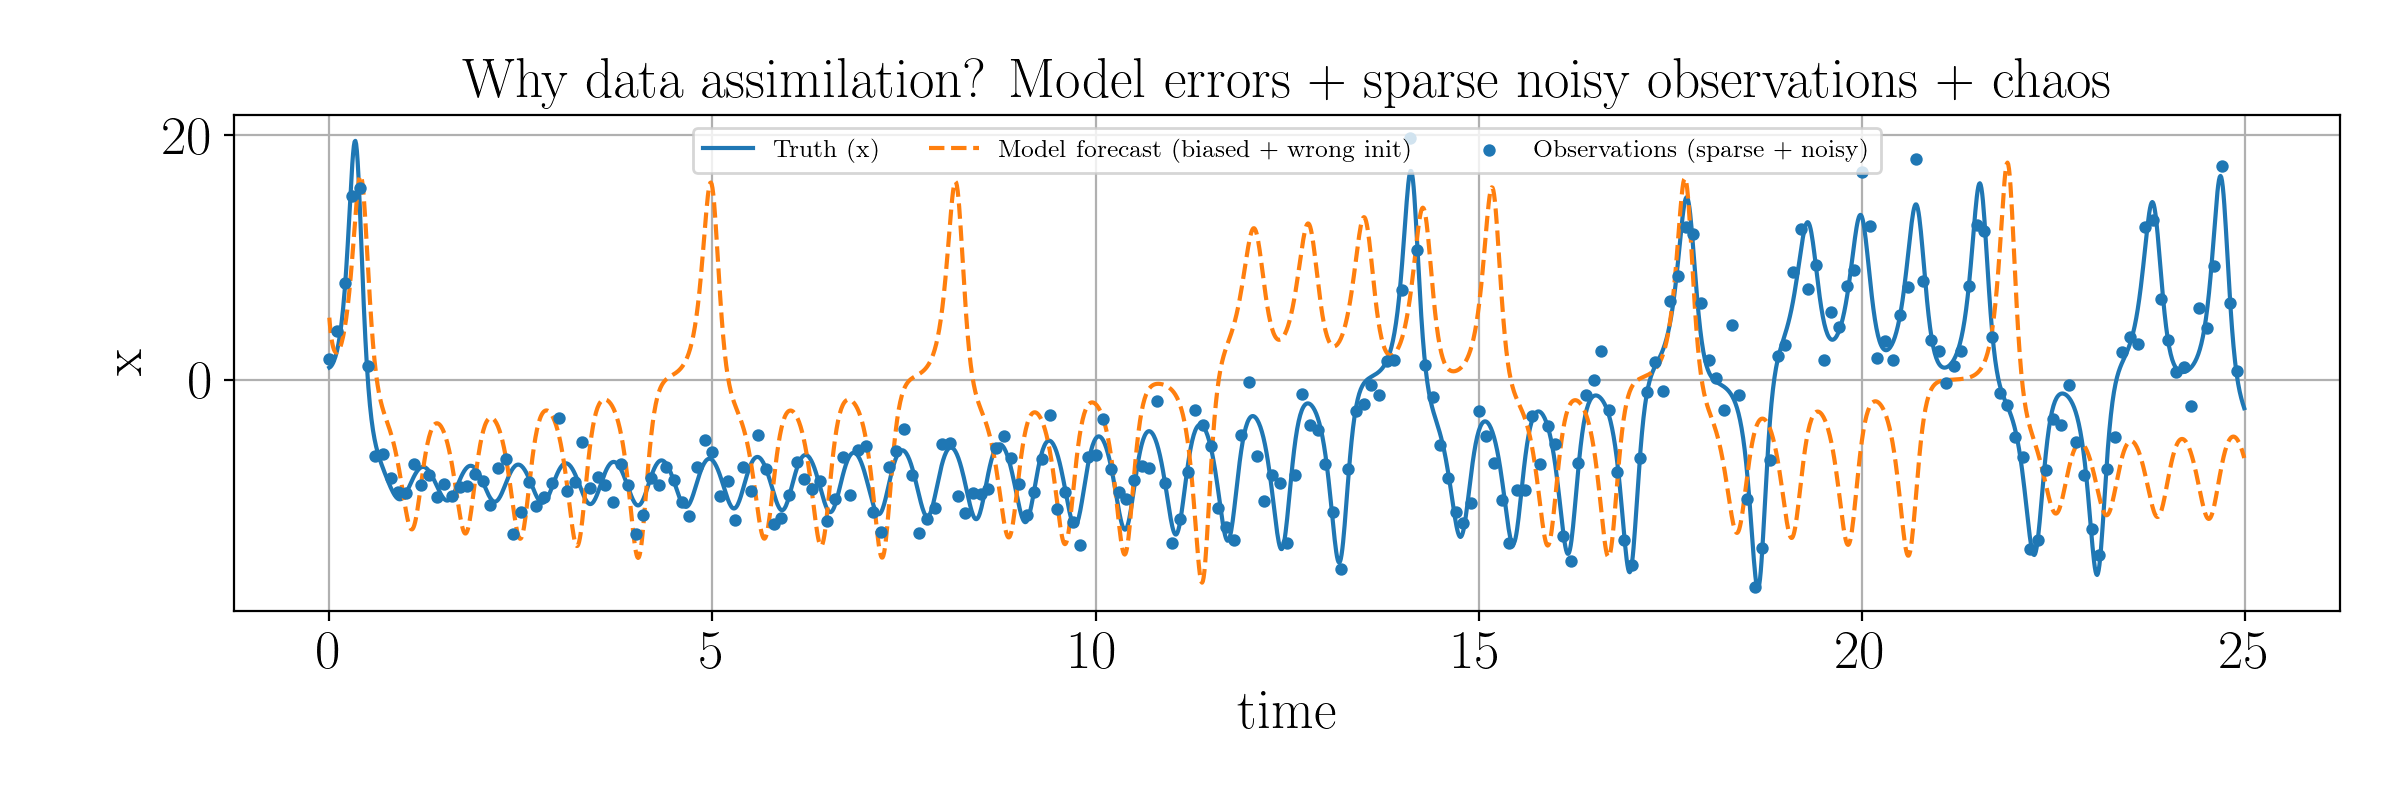

In [10]:
display(Image(filename="imagenes/intro_timeseries_model_vs_obs.png"))

## Why data assimilation? (II) Same physics, wrong state

In this phase portrait (x–z plane), both trajectories evolve on the **same attractor**.

- The blue curve represents the *true system*.
- The dashed curve represents the *model simulation*.

The model clearly captures the **correct dynamical regime** and the **global structure of the system**.  
However, it does **not** follow the same trajectory in state space.

This highlights a crucial distinction:

> **Being in the right dynamical regime does not mean being in the right state.**

In chaotic systems, even small mismatches in state matter.  
Two trajectories on the same attractor can correspond to **completely different instantaneous states**.

Therefore, a model can be physically correct and still provide a poor estimate of the actual system state.


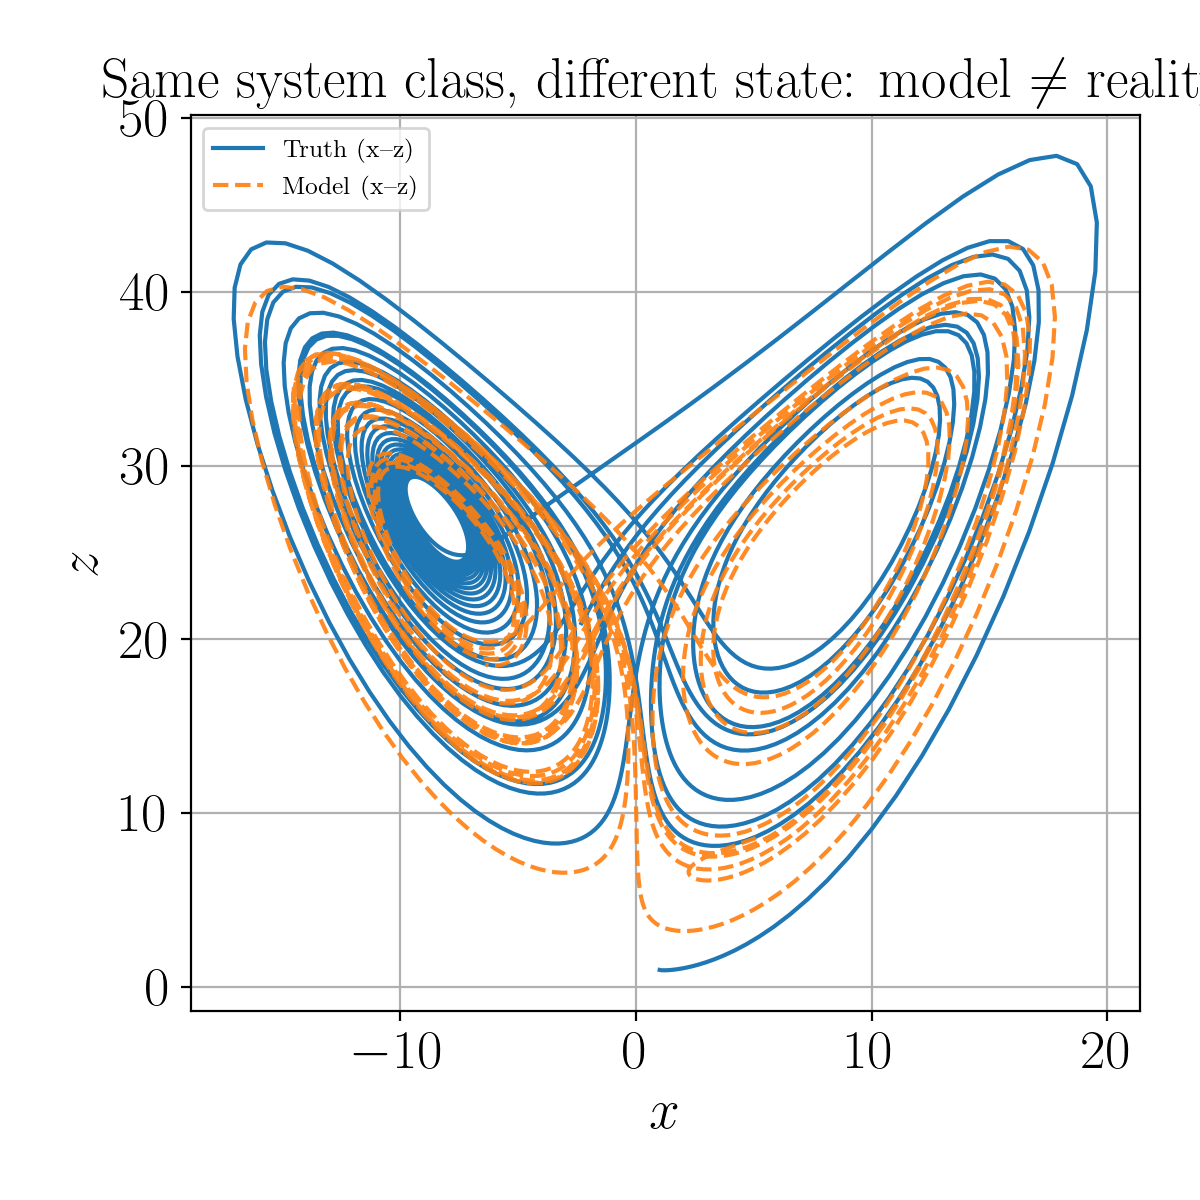

In [11]:
display(Image(filename="imagenes/intro_phase_portrait.png"))

## Why data assimilation? (III) Models and data are insufficient on their own

The final figure combines all sources of difficulty:

- The **true state** (solid line)
- A **free model forecast** with biased parameters and wrong initial condition (dashed line)
- **Sparse and noisy observations** (points)

The limitations are clear:

- The model forecast diverges from reality due to chaos and model error.
- The observations are incomplete, noisy, and provide no dynamical information by themselves.

Neither source alone is sufficient to estimate the true system state.

This leads to a key conclusion:

> **Neither the model nor the data are wrong.  
> They are simply insufficient on their own.**


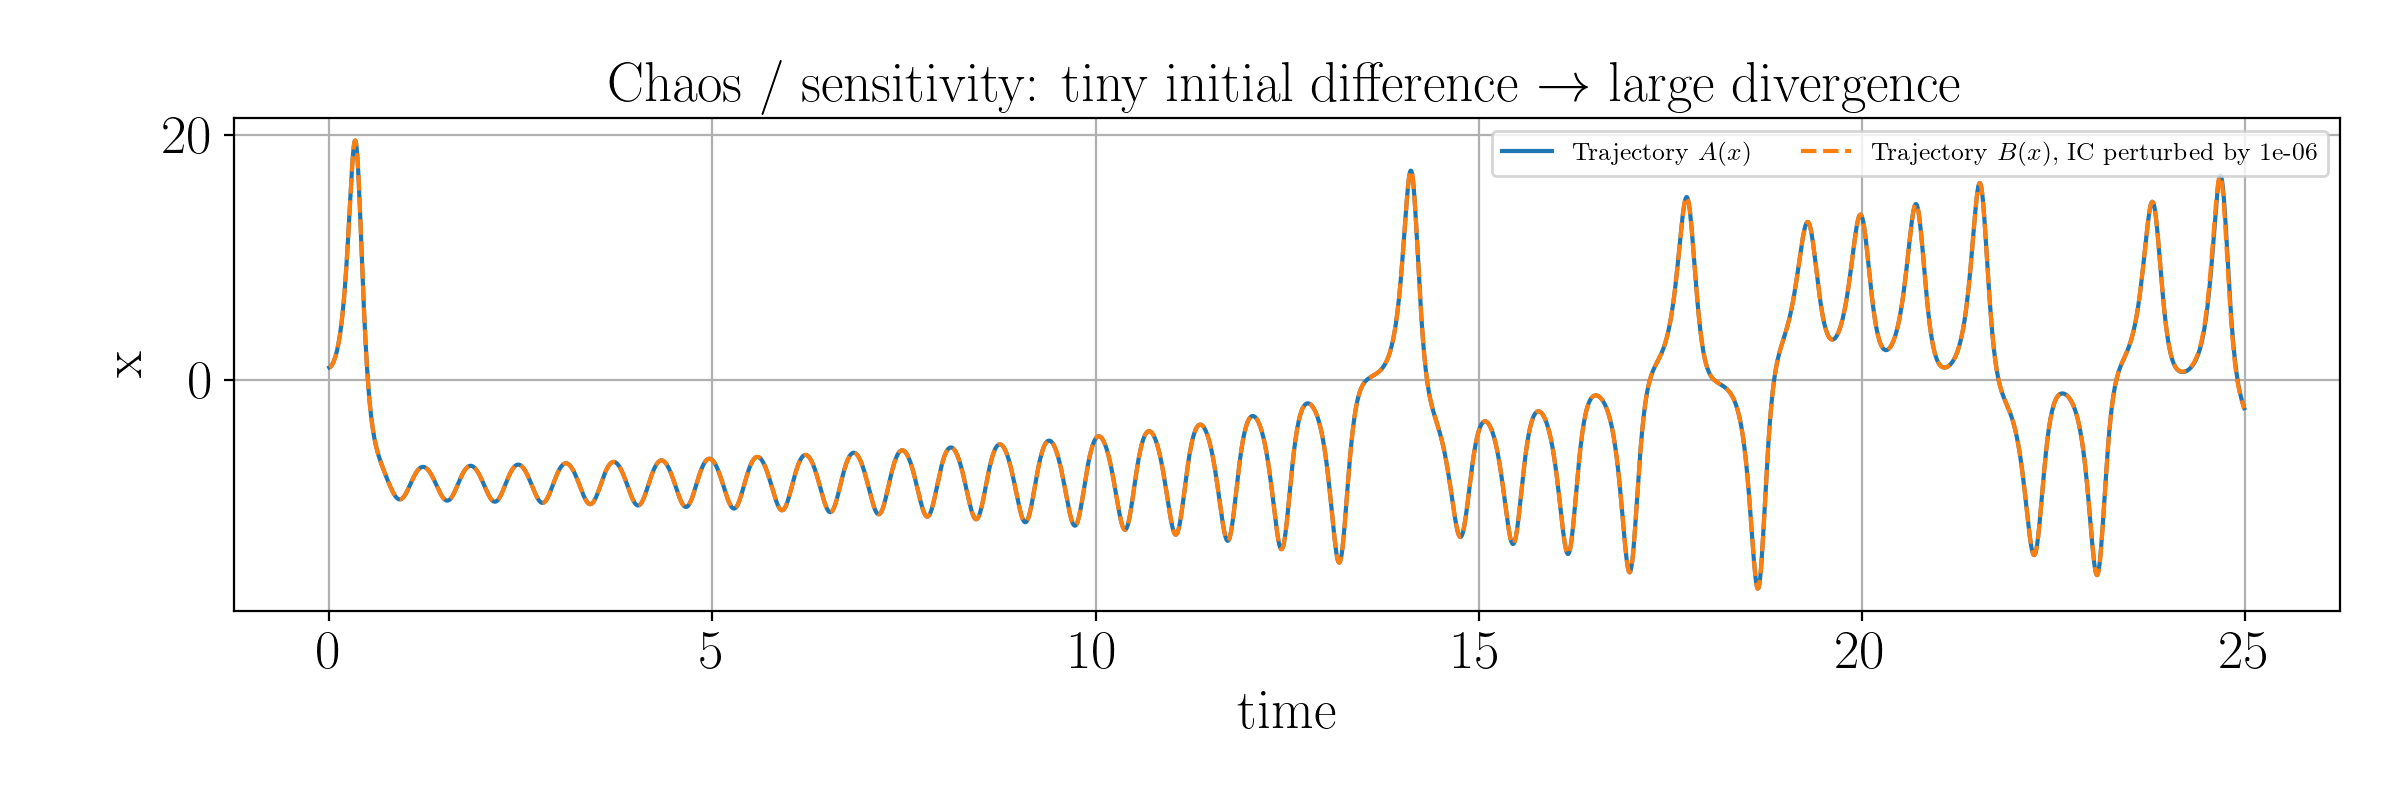

In [12]:
display(Image(filename="imagenes/intro_chaos_two_trajectories.png"))

## The role of data assimilation

Data assimilation addresses this problem by **combining models and observations under uncertainty**.

- The **model** provides dynamical consistency.
- The **observations** anchor the estimate to reality.
- Data assimilation determines the **best possible estimate of the system state** given both sources and their uncertainties.

Importantly, data assimilation:
- does **not** fix incorrect physics,
- does **not** remove chaos,
- and does **not** replace measurements.

Instead, it continuously reconciles imperfect models and imperfect data to track the evolving state of complex systems.
